# Linear Regression
# Student Name: Aminullahi Zainab
# Course: Linear Regression_Assignment.ipynb
# Date:18th May, 2026

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# Load dataset
data = pd.read_csv('data.csv')

# Display first rows
print(data.head())

            date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  5/2/2014 0:00   313000.0         3       1.50         1340      7912   
1  5/2/2014 0:00  2384000.0         5       2.50         3650      9050   
2  5/2/2014 0:00   342000.0         3       2.00         1930     11947   
3  5/2/2014 0:00   420000.0         3       2.25         2000      8030   
4  5/2/2014 0:00   550000.0         4       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    street       city  statezip country  
0

In [6]:
# Drop 'yr_renovated'
data = data.drop(columns=['yr_renovated'])

In [7]:
# Target variable
y = data['price']

# Features
X = data.drop(columns=['price'])

In [8]:
# Convert categorical variables if any
X = pd.get_dummies(X, drop_first=True)

In [9]:
#  Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
# Normalize Data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Train Linear Rregression Model

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# Making the predictions

y_pred = model.predict(X_test_scaled)

In [13]:
# Evaluating the performance 

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")

MODEL PERFORMANCE
Mean Absolute Error (MAE): 289125.14177745476
Mean Squared Error (MSE): 1147028602610.3845
Root Mean Squared Error (RMSE): 1070994.2122207684
R² Score: -0.12470727944434579


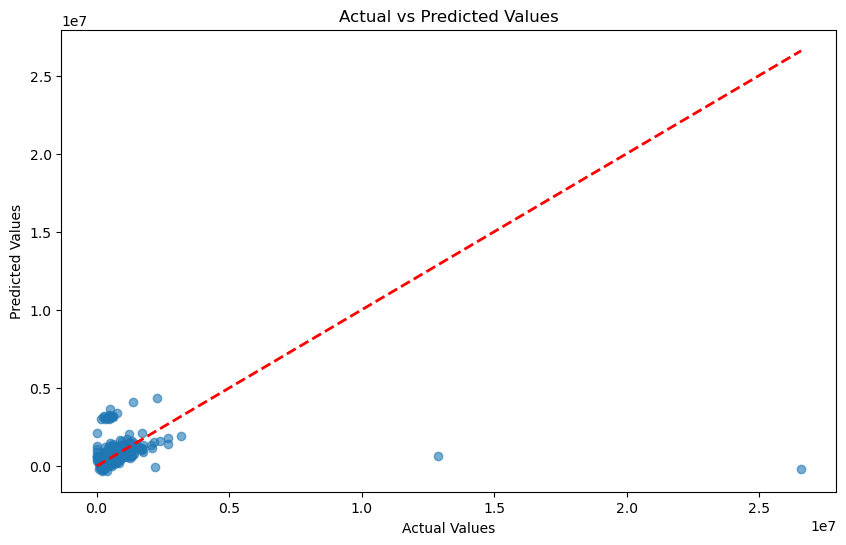

In [14]:
#  Actual VS Predicted Plot

plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction diagonal line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

# Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.show()